<a href="https://colab.research.google.com/github/joyangelai/Colabs-Vol-2/blob/main/KNN_NEIGH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KNN NEAREST NEIGHBOURS

In [ ]:
# import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics  import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# load dataset
data = pd.read_csv("/content/Classified Data.txt")
data.head()

,Unnamed: 0,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ,TARGET CLASS
0,0,0.913917,1.162073,0.567946,0.755464,0.780862,0.352608,0.759697,0.643798,0.879422,1.231409,1
1,1,0.635632,1.003722,0.535342,0.825645,0.924109,0.648450,0.675334,1.013546,0.621552,1.492702,0
2,2,0.721360,1.201493,0.921990,0.855595,1.526629,0.720781,1.626351,1.154483,0.957877,1.285597,0
3,3,1.234204,1.386726,0.653046,0.825624,1.142504,0.875128,1.409708,1.380003,1.522692,1.153093,1
4,4,1.279491,0.949750,0.627280,0.668976,1.232537,0.703727,1.115596,0.646691,1.463812,1.419167,1


In [ ]:
# drop first column
#del data['Unnamed: 0']


In [ ]:
data.head()

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ,TARGET CLASS
0,0.913917,1.162073,0.567946,0.755464,0.780862,0.352608,0.759697,0.643798,0.879422,1.231409,1
1,0.635632,1.003722,0.535342,0.825645,0.924109,0.648450,0.675334,1.013546,0.621552,1.492702,0
2,0.721360,1.201493,0.921990,0.855595,1.526629,0.720781,1.626351,1.154483,0.957877,1.285597,0
3,1.234204,1.386726,0.653046,0.825624,1.142504,0.875128,1.409708,1.380003,1.522692,1.153093,1
4,1.279491,0.949750,0.627280,0.668976,1.232537,0.703727,1.115596,0.646691,1.463812,1.419167,1


In [ ]:
# checking null values
data.isnull().sum().any()

np.False_

In [ ]:
# Preparing data for modeling
X = data.drop('TARGET CLASS', axis = 1)
y = data['TARGET CLASS']

In [ ]:
# Split using train,test, split
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state= 42, test_size= 0.2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 10), (200, 10), (800,), (200,))

In [ ]:
# scaling features
scale = StandardScaler()
X_train_s = scale.fit_transform(X_train)
X_test_s = scale.transform(X_test)

In [ ]:
# creating model
model = KNeighborsClassifier(n_neighbors=4)
model.fit(X_train_s, y_train)


KNeighborsClassifier(n_neighbors=4)

In [ ]:
# predict the model
y_pred = model.predict(X_test_s)
y_pred[:10]

array([0, 1, 1, 1, 0, 1, 0, 1, 0, 1])

In [ ]:
# check accuracy
print(f"{accuracy_score(y_test,y_pred):.2f}%")

0.95%


In [ ]:
# confusion matrix
print(confusion_matrix(y_test, y_pred))

[[95  3]
 [ 7 95]]


In [ ]:
# check classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95        98
           1       0.97      0.93      0.95       102

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200



In [ ]:
# roc score
roc_auc_score(y_test,y_pred)

np.float64(0.9503801520608243)

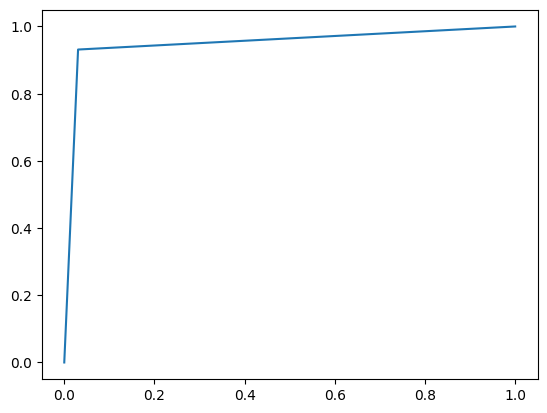

In [ ]:
# roc curve plot
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
plt.plot(fpr, tpr);